Sketch processed and saved to /data/home/huixian/Documents/677_project/fashion/fashion-dataset/feature/2272_feature.jpg


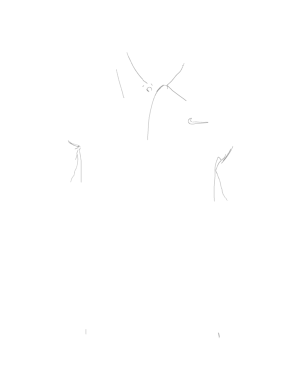

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Read the sketch image
sketch_iamge_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/sketches/2272_sketch.png"
output_sketch_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/feature/2272_feature.jpg"

# Load image as grayscale
sketch = Image.open(sketch_iamge_path).convert('L')
sketch_np = np.array(sketch)

# Process: First right-to-left (row-wise)
for i in range(sketch_np.shape[0]):  # For each row
    for j in range(sketch_np.shape[1]-1, -1, -1):  # Right to left
        if sketch_np[i, j] < 128:  # Pixel is black
            sketch_np[i, j] = 255  # Turn white
            break  # Only first black pixel

# Process: Then left-to-right (row-wise)
for i in range(sketch_np.shape[0]):  # For each row
    for j in range(sketch_np.shape[1]):  # Left to right
        if sketch_np[i, j] < 128:
            sketch_np[i, j] = 255
            break

# Now column-wise processing

# Process: Top to bottom (column-wise)
for j in range(sketch_np.shape[1]):  # For each column
    for i in range(sketch_np.shape[0]):  # Top to bottom
        if sketch_np[i, j] < 128:
            sketch_np[i, j] = 255
            break

# Process: Bottom to top (column-wise)
for j in range(sketch_np.shape[1]):  # For each column
    for i in range(sketch_np.shape[0]-1, -1, -1):  # Bottom to top
        if sketch_np[i, j] < 128:
            sketch_np[i, j] = 255
            break

# Save the modified sketch
sketch_processed = Image.fromarray(sketch_np)
sketch_processed.save(output_sketch_path)

# Print confirmation
print("Sketch processed and saved to", output_sketch_path)

# Show the processed sketch
plt.imshow(sketch_processed, cmap='gray')
plt.axis('off')
plt.show()

sketch_iamge_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/sketches/2272_sketch.png"
output_gaussian_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/gaussian/2272_gaussian.jpg"



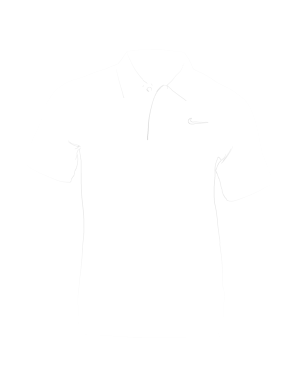

True

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

sketch_iamge_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/sketches/2272_sketch.png"
output_gaussian_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/gaussian/2272_gaussian_03.jpg"


# Load black-and-white image
img = cv2.imread(sketch_iamge_path, cv2.IMREAD_GRAYSCALE)

# Binarize just in case (black:0, white:255)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Get image dimensions
h, w = binary.shape

# Generate coordinate grid
x = np.linspace(-1, 1, w)
y = np.linspace(-1, 1, h)
xv, yv = np.meshgrid(x, y)

# 2D Gaussian mask
sigma = 0.3  # adjust for how sharp you want
gaussian = np.exp(-(xv**2 + yv**2) / (2 * sigma**2))
gaussian = gaussian / gaussian.max()

# Prepare output image (start from white)
output = np.ones_like(binary) * 255

# Only modify black pixels
black_mask = (binary == 0)

# For black pixels, apply the gaussian scaling
# Closer to center => darker (lower value), edge => lighter (closer to 255)
output[black_mask] = (1 - gaussian[black_mask]) * 255

# Convert to uint8
output = output.astype(np.uint8)

# Save or display
plt.imshow(output, cmap='gray')
plt.axis('off')
plt.show()
cv2.imwrite(output_gaussian_path, output)


In [ ]:
input_folder = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/images/"
filename = "1528.jpg"

image_path = os.path.join(input_folder, filename)
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur (optional, reduces noise)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 🧵 Apply Canny edge detection
edges = cv2.Canny(blurred, low_threshold, high_threshold)

# Invert for scribble-style (black on white)
sketch = 255 - edges

# Save as PNG
out_path = os.path.join(output_folder, os.path.splitext(filename)[0] + "_sketch.png")
cv2.imwrite(out_path, sketch)